# Experimentacion de aprendizaje no supervisado

Este cuaderno registra configuraciones, metricas y criterios de seleccion para PCA, HAC, K-Means, t-SNE y UMAP. Los resultados se calculan desde el codigo del proyecto; las conclusiones deben escribirse despues de ejecutar las celdas.

## Criterios de comparacion
- PCA: conservar la menor cantidad de componentes que explique al menos el 90% de la varianza, considerando tambien la interpretabilidad de las cargas.
- HAC y K-Means: contrastar silhouette (mayor es mejor), Davies-Bouldin (menor es mejor), Calinski-Harabasz (mayor es mejor) y, para HAC, correlacion cofenetica (mayor indica mejor representacion de distancias). Ninguna metrica demuestra por si sola que los grupos sean verdaderos.
- t-SNE y UMAP: comparar trustworthiness y la legibilidad de la estructura local en las graficas. No elegir solo por silhouette calculado sobre las coordenadas 2D.

El proyecto aplica one-hot encoding y StandardScaler dentro de `preparar_datos_numericos`. Se excluye la etiqueta `Drug` de los predictores para evitar fuga de informacion.

In [1]:
from pathlib import Path
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SRC_DIR = ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from unsupervised import UnsupervisedAnalysis

RUTA_CSV = ROOT / "data" / "drug200.csv"
COLUMNAS_EXCLUIR = ["Drug"]  # Para Mall_Customers.csv, por ejemplo: ["CustomerID"]

analisis = UnsupervisedAnalysis()
datos = analisis.cargar_csv(RUTA_CSV)
columnas_excluir = [col for col in COLUMNAS_EXCLUIR if col in datos.columns]
analisis.dataframe = datos.drop(columns=columnas_excluir)

if analisis.dataframe.isna().any().any():
    raise ValueError("Hay valores nulos; imputelos antes de ejecutar los experimentos.")
if len(analisis.dataframe) < 6:
    raise ValueError("Se requieren al menos 6 filas para comparar estas configuraciones.")

X_escalado, nombres_variables = analisis.preparar_datos_numericos()
n_muestras, n_variables = X_escalado.shape
if n_variables < 2:
    raise ValueError("Se requieren al menos 2 variables numericas/codificadas.")

print(f"Archivo: {RUTA_CSV}")
print(f"Filas: {n_muestras} | variables tras codificacion: {n_variables}")
print(f"Columnas excluidas: {columnas_excluir or 'ninguna'}")
display(datos.head())
display(pd.Series(nombres_variables, name="Variable codificada").to_frame())

ModuleNotFoundError: No module named 'matplotlib'

## 1. PCA

La configuracion de referencia conserva dos componentes, sin blanqueo y con el solver automatico. Se compara con tres componentes, el umbral automatico del 90% y blanqueo. PCA no es un algoritmo de clustering: aqui se selecciona por compresion de varianza y facilidad de interpretacion.

PCA - Varianza explicada acumulada: 45.82%
PCA - Varianza explicada acumulada: 62.82%
PCA - Varianza explicada acumulada: 91.26%
PCA - Varianza explicada acumulada: 45.82%


,Configuracion,Componentes,Varianza explicada acumulada,Whiten
0,Estandar: 2 componentes,2,45.82%,False
3,Variacion: blanqueo,2,45.82%,True
1,Variacion: 3 componentes,3,62.82%,False
2,Variacion: umbral 90%,5,91.26%,False


PCA - Varianza explicada acumulada: 100.00%
Componentes minimos para >=90% de varianza: 5


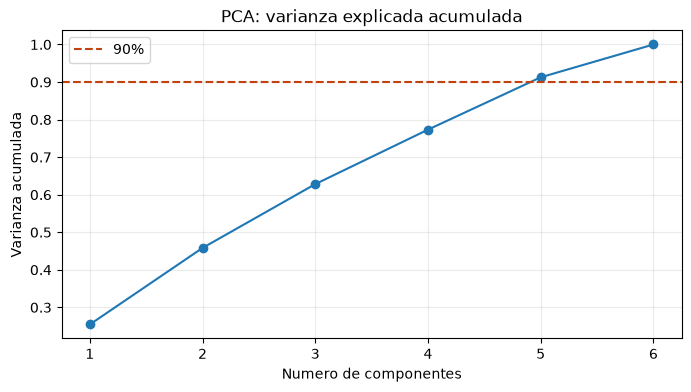

Seleccion preliminar PCA: Variacion: umbral 90%
Cargas de mayor magnitud en PC1:


,Magnitud absoluta
BP_NORMAL,0.843188
BP_LOW,0.797141
Cholesterol_NORMAL,0.282370
Na_to_K,0.281140
Age,0.134986
Sex_M,0.102145


Cargas de mayor magnitud en PC2:


,Magnitud absoluta
Sex_M,0.646880
Age,0.622126
Na_to_K,0.566517
Cholesterol_NORMAL,0.255170
BP_LOW,0.179705
BP_NORMAL,0.073508


In [2]:
configuraciones_pca = [
    ("Estandar: 2 componentes", 2, False, "auto"),
    ("Variacion: 3 componentes", min(3, n_variables), False, "auto"),
    ("Variacion: umbral 90%", 0.90, False, "auto"),
    ("Variacion: blanqueo", 2, True, "auto"),
]
resultados_pca = {}
filas_pca = []
for nombre, componentes, blanquear, solver in configuraciones_pca:
    resultado = analisis.pca(
        n_components=componentes, whiten=blanquear, svd_solver=solver
    )
    resultados_pca[nombre] = resultado
    filas_pca.append({
        "Configuracion": nombre,
        "Componentes": resultado["componentes"].shape[1],
        "Varianza explicada acumulada": resultado["varianza_acumulada"][-1],
        "Whiten": blanquear,
    })

tabla_pca = pd.DataFrame(filas_pca).sort_values("Componentes")
display(tabla_pca.style.format({"Varianza explicada acumulada": "{:.2%}"}))

pca_completo = analisis.pca(n_components=None)
varianza_acumulada = pca_completo["varianza_acumulada"]
cantidad_90 = int(np.searchsorted(varianza_acumulada, 0.90) + 1)
print(f"Componentes minimos para >=90% de varianza: {cantidad_90}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, len(varianza_acumulada) + 1), varianza_acumulada, marker="o")
ax.axhline(0.90, color="#c2410c", linestyle="--", label="90%")
ax.set(xlabel="Numero de componentes", ylabel="Varianza acumulada", title="PCA: varianza explicada acumulada")
ax.legend()
ax.grid(alpha=0.25)
plt.show()

candidatos_pca = [
    (nombre, resultado) for nombre, resultado in resultados_pca.items()
    if resultado["varianza_acumulada"][-1] >= 0.90
]
if candidatos_pca:
    seleccion_pca_nombre, seleccion_pca = min(
        candidatos_pca, key=lambda item: item[1]["componentes"].shape[1]
    )
else:
    seleccion_pca_nombre, seleccion_pca = (
        "PCA completo (respaldo)", pca_completo
    )
print(f"Seleccion preliminar PCA: {seleccion_pca_nombre}")

cargas = seleccion_pca["cargas"]
for componente in cargas.columns[:2]:
    print(f"Cargas de mayor magnitud en {componente}:")
    display(cargas[componente].abs().sort_values(ascending=False).head(10).to_frame("Magnitud absoluta"))

**Análisis PCA:** Se seleccionó la configuración de umbral 90% con 5 componentes, alcanzando 91.26% de varianza explicada acumulada, suficiente para preservar la información relevante en los métodos posteriores.


## 2. HAC (clustering jerarquico aglomerativo)

La referencia usa tres clusters y enlace Ward. Las variaciones prueban Ward, complete y average con distintos numeros de clusters. Se usa distancia euclidiana; Ward requiere esta metrica. La correlacion cofenetica se calcula con la matriz de enlace de SciPy.

In [3]:
def metricas_clustering(X, etiquetas):
    etiquetas = np.asarray(etiquetas)
    cantidad = np.unique(etiquetas).size
    if cantidad < 2 or cantidad >= len(etiquetas):
        return {"silhouette": np.nan, "davies_bouldin": np.nan, "calinski_harabasz": np.nan}
    return {
        "silhouette": float(__import__("sklearn.metrics", fromlist=["silhouette_score"]).silhouette_score(X, etiquetas)),
        "davies_bouldin": float(davies_bouldin_score(X, etiquetas)),
        "calinski_harabasz": float(calinski_harabasz_score(X, etiquetas)),
    }

valores_k = list(range(2, min(5, n_muestras - 1) + 1))
configuraciones_hac = [
    (k, enlace) for enlace in ("ward", "complete", "average")
    for k in valores_k
]
resultados_hac = {}
filas_hac = []
for k, enlace in configuraciones_hac:
    resultado = analisis.hac(n_clusters=k, linkage=enlace, metric="euclidean")
    etiquetas = resultado["resultado"]["cluster"].to_numpy()
    metricas = metricas_clustering(X_escalado, etiquetas)
    matriz_enlaces = scipy_linkage(X_escalado, method=enlace, metric="euclidean")
    cofenetica, _ = cophenet(matriz_enlaces, pdist(X_escalado))
    nombre = f"k={k}, linkage={enlace}"
    resultados_hac[nombre] = {"resultado": resultado, "etiquetas": etiquetas}
    filas_hac.append({
        "Configuracion": nombre, "k": k, "linkage": enlace,
        **metricas, "cophenetica": float(cofenetica),
    })

tabla_hac = pd.DataFrame(filas_hac)
tabla_hac["rango_compuesto"] = (
    tabla_hac["silhouette"].rank(ascending=False)
    + tabla_hac["davies_bouldin"].rank(ascending=True)
    + tabla_hac["calinski_harabasz"].rank(ascending=False)
    + tabla_hac["cophenetica"].rank(ascending=False)
) / 4
display(tabla_hac.sort_values("rango_compuesto").style.format({
    "silhouette": "{:.3f}", "davies_bouldin": "{:.3f}",
    "calinski_harabasz": "{:.1f}", "cophenetica": "{:.3f}",
    "rango_compuesto": "{:.2f}",
}))

mejor_hac = tabla_hac.sort_values("rango_compuesto").iloc[0]
seleccion_hac_nombre = mejor_hac["Configuracion"]
seleccion_hac = resultados_hac[seleccion_hac_nombre]
print(f"Seleccion preliminar HAC: {seleccion_hac_nombre}")

HAC - Correlación cofenética: 0.6330
HAC - Correlación cofenética: 0.6330
HAC - Correlación cofenética: 0.6330
HAC - Correlación cofenética: 0.6330
HAC - Correlación cofenética: 0.6071
HAC - Correlación cofenética: 0.6071
HAC - Correlación cofenética: 0.6071
HAC - Correlación cofenética: 0.6071
HAC - Correlación cofenética: 0.7114
HAC - Correlación cofenética: 0.7114
HAC - Correlación cofenética: 0.7114
HAC - Correlación cofenética: 0.7114


,Configuracion,k,linkage,silhouette,davies_bouldin,calinski_harabasz,cophenetica,rango_compuesto
10,"k=4, linkage=average",4,average,0.225,1.661,42.9,0.711,3.38
3,"k=5, linkage=ward",5,ward,0.229,1.595,41.6,0.633,3.88
11,"k=5, linkage=average",5,average,0.210,1.550,34.3,0.711,4.12
0,"k=2, linkage=ward",2,ward,0.218,1.690,51.8,0.633,4.38
2,"k=4, linkage=ward",4,ward,0.216,1.651,44.7,0.633,4.38
1,"k=3, linkage=ward",3,ward,0.231,1.827,49.6,0.633,4.62
9,"k=3, linkage=average",3,average,0.200,1.687,37.2,0.711,5.12
8,"k=2, linkage=average",2,average,0.171,1.717,16.1,0.711,7.38
7,"k=5, linkage=complete",5,complete,0.144,1.762,28.3,0.607,9.38
6,"k=4, linkage=complete",4,complete,0.142,2.001,30.8,0.607,9.88


Seleccion preliminar HAC: k=4, linkage=average


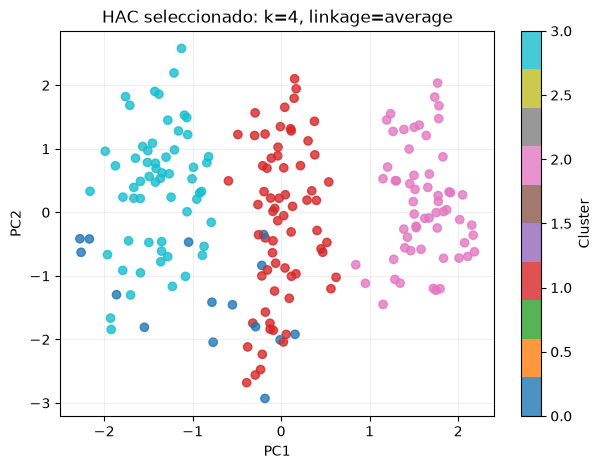

In [6]:
proyeccion_pca = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X_escalado)
fig, ax = plt.subplots(figsize=(7, 5))
puntos = ax.scatter(proyeccion_pca[:, 0], proyeccion_pca[:, 1], c=seleccion_hac["etiquetas"], cmap="tab10", alpha=0.8)
ax.set(title=f"HAC seleccionado: {seleccion_hac_nombre}", xlabel="PC1", ylabel="PC2")
fig.colorbar(puntos, ax=ax, label="Cluster")
ax.grid(alpha=0.2)
plt.show()

**Análisis HAC:** La configuración k=4, linkage=average obtuvo el mejor rango compuesto, destacando por su alta correlación cofenética (0.711), aunque con silhouette moderado (0.225) y un cluster disperso sin región propia en la proyección.


## 3. K-Means

La referencia usa k=3, inicializacion `k-means++` y 10 reinicios. Se comparan k=2 a 6, ambas inicializaciones y 10/20 reinicios. El estado aleatorio esta fijado a 42 por la implementacion del proyecto. La inercia siempre tiende a disminuir al aumentar k; se interpreta con el codo y las metricas, no de forma aislada.

c:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


K-Means - Silhouette score: 0.2180
K-Means - Silhouette score: 0.2180
K-Means - Silhouette score: 0.2180
K-Means - Silhouette score: 0.2375
K-Means - Silhouette score: 0.2375


c:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than availabl

K-Means - Silhouette score: 0.2375
K-Means - Silhouette score: 0.2174
K-Means - Silhouette score: 0.2174
K-Means - Silhouette score: 0.2199
K-Means - Silhouette score: 0.2412


c:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than availabl

K-Means - Silhouette score: 0.2385
K-Means - Silhouette score: 0.2412
K-Means - Silhouette score: 0.2361
K-Means - Silhouette score: 0.2573
K-Means - Silhouette score: 0.2361


c:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,Configuracion,k,init,n_init,silhouette,davies_bouldin,calinski_harabasz,inercia
13,"k=6, init=random, n_init=10",6,random,10,0.257,1.569,42.7,571.3
9,"k=5, init=k-means++, n_init=10",5,k-means++,10,0.241,1.552,44.0,630.8
11,"k=5, init=k-means++, n_init=20",5,k-means++,20,0.241,1.552,44.0,630.8
10,"k=5, init=random, n_init=10",5,random,10,0.239,1.562,43.9,631.6
3,"k=3, init=k-means++, n_init=10",3,k-means++,10,0.238,1.783,51.7,786.9
4,"k=3, init=random, n_init=10",3,random,10,0.238,1.783,51.7,786.9
5,"k=3, init=k-means++, n_init=20",3,k-means++,20,0.238,1.783,51.7,786.9
12,"k=6, init=k-means++, n_init=10",6,k-means++,10,0.236,1.475,41.7,578.4
14,"k=6, init=k-means++, n_init=20",6,k-means++,20,0.236,1.475,41.7,578.4
8,"k=4, init=k-means++, n_init=20",4,k-means++,20,0.220,1.526,47.4,695.5


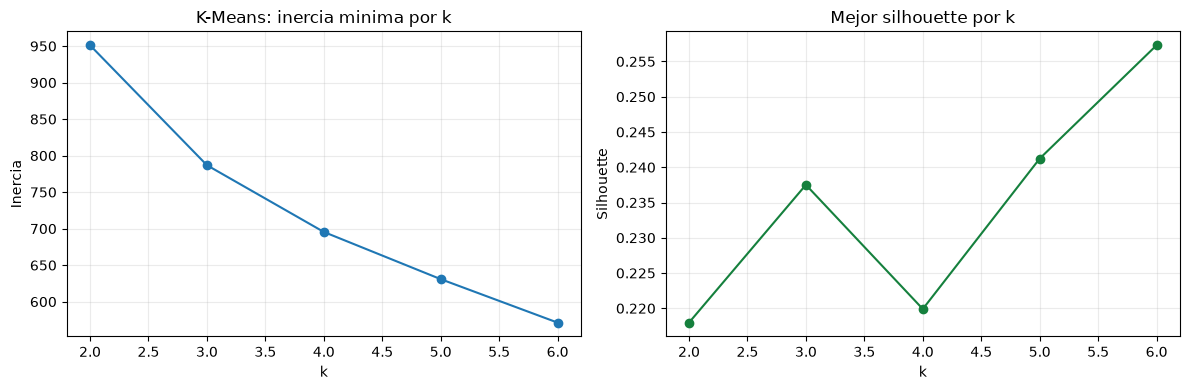

Seleccion preliminar K-Means: k=6, init=random, n_init=10


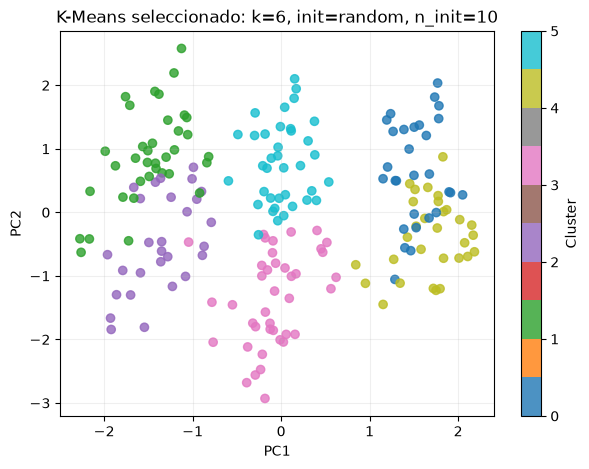

In [7]:
valores_k_kmeans = list(range(2, min(6, n_muestras - 1) + 1))
configuraciones_kmeans = [
    (k, inicio, reinicios)
    for k in valores_k_kmeans
    for inicio, reinicios in [("k-means++", 10), ("random", 10), ("k-means++", 20)]
]
resultados_kmeans = {}
filas_kmeans = []
for k, inicio, reinicios in configuraciones_kmeans:
    resultado = analisis.kmeans(n_clusters=k, init=inicio, n_init=reinicios)
    etiquetas = resultado["resultado"]["cluster"].to_numpy()
    nombre = f"k={k}, init={inicio}, n_init={reinicios}"
    resultados_kmeans[nombre] = {"resultado": resultado, "etiquetas": etiquetas}
    filas_kmeans.append({
        "Configuracion": nombre, "k": k, "init": inicio, "n_init": reinicios,
        **metricas_clustering(X_escalado, etiquetas),
        "inercia": resultado["inercia"],
    })

tabla_kmeans = pd.DataFrame(filas_kmeans)
display(tabla_kmeans.sort_values("silhouette", ascending=False).style.format({
    "silhouette": "{:.3f}", "davies_bouldin": "{:.3f}",
    "calinski_harabasz": "{:.1f}", "inercia": "{:.1f}",
}))

fig, ejes = plt.subplots(1, 2, figsize=(12, 4))
por_k = tabla_kmeans.groupby("k").agg(inercia=("inercia", "min"), silhouette=("silhouette", "max"))
ejes[0].plot(por_k.index, por_k["inercia"], marker="o")
ejes[0].set(title="K-Means: inercia minima por k", xlabel="k", ylabel="Inercia")
ejes[1].plot(por_k.index, por_k["silhouette"], marker="o", color="#15803d")
ejes[1].set(title="Mejor silhouette por k", xlabel="k", ylabel="Silhouette")
for ax in ejes: ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

mejor_kmeans = tabla_kmeans.sort_values("silhouette", ascending=False).iloc[0]
seleccion_kmeans_nombre = mejor_kmeans["Configuracion"]
seleccion_kmeans = resultados_kmeans[seleccion_kmeans_nombre]
print(f"Seleccion preliminar K-Means: {seleccion_kmeans_nombre}")

fig, ax = plt.subplots(figsize=(7, 5))
puntos = ax.scatter(proyeccion_pca[:, 0], proyeccion_pca[:, 1], c=seleccion_kmeans["etiquetas"], cmap="tab10", alpha=0.8)
ax.set(title=f"K-Means seleccionado: {seleccion_kmeans_nombre}", xlabel="PC1", ylabel="PC2")
fig.colorbar(puntos, ax=ax, label="Cluster")
ax.grid(alpha=0.2)
plt.show()

**Análisis K-Means:** Se eligió k=6 (init=random, n_init=10) por su mayor silhouette (0.257), aunque este no es monótono al variar k, y dos de los clusters se entremezclan visualmente en la proyección.


## 4. t-SNE y UMAP

Se comparan embeddings bidimensionales. La trustworthiness cuantifica cuanto se preservan vecinos locales. Es una evidencia complementaria: inspeccione tambien si las estructuras visuales son claras y estables ante cambios de parametros. Las distancias entre grupos separados en estos graficos no siempre representan distancias globales fieles.

t-SNE - Trustworthiness: 0.9959
t-SNE - Trustworthiness: 0.9958
t-SNE - Trustworthiness: 0.9979
t-SNE - Trustworthiness: 0.9978
t-SNE - Trustworthiness: 0.9981
t-SNE - Trustworthiness: 0.9980


,Configuracion,perplexity,learning_rate,trustworthiness
4,"perplexity=30, learning_rate=auto",30.000000,auto,0.9981
5,"perplexity=30, learning_rate=200",30.000000,200,0.9980
2,"perplexity=15, learning_rate=auto",15.000000,auto,0.9979
3,"perplexity=15, learning_rate=200",15.000000,200,0.9978
0,"perplexity=5, learning_rate=auto",5.000000,auto,0.9959
1,"perplexity=5, learning_rate=200",5.000000,200,0.9958


Seleccion preliminar t-SNE: perplexity=30, learning_rate=auto


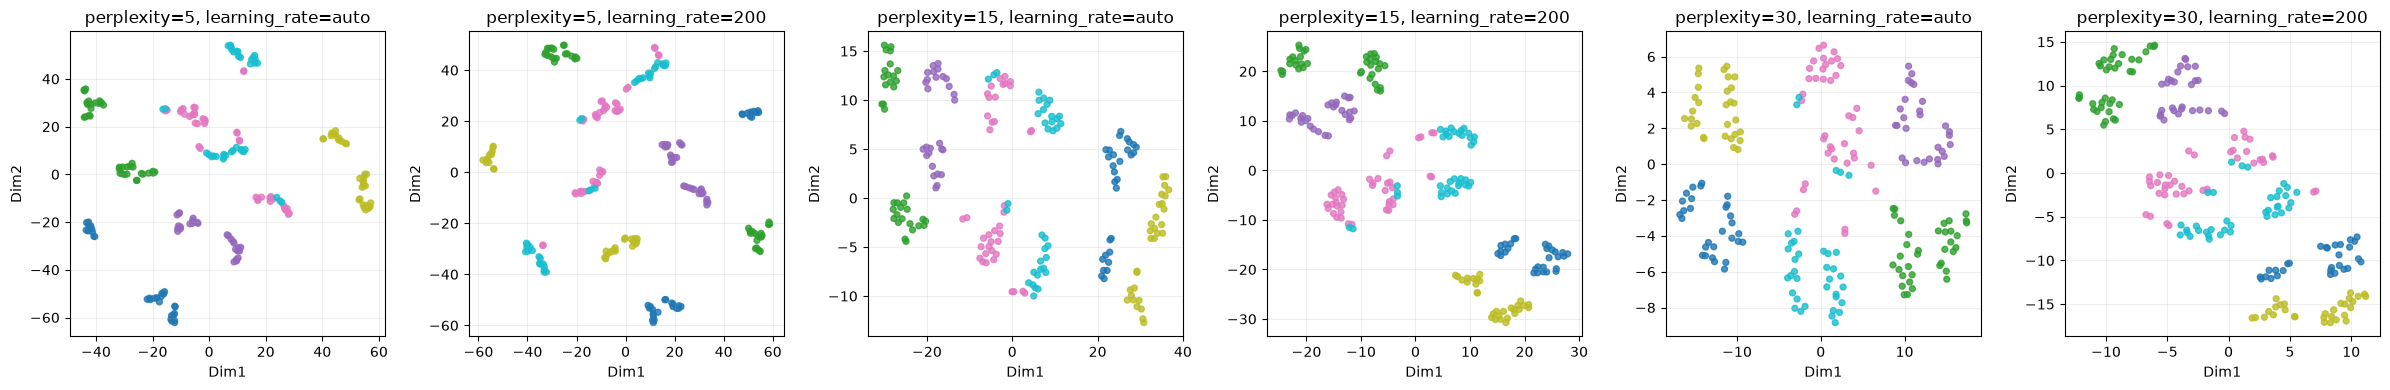

In [8]:
perplexidades = sorted({p for p in (5.0, 15.0, 30.0) if p < n_muestras})
configuraciones_tsne = [(p, tasa) for p in perplexidades for tasa in ("auto", 200)]
resultados_tsne = {}
filas_tsne = []
for perplexity, learning_rate in configuraciones_tsne:
    embedding = analisis.tsne(n_components=2, perplexity=perplexity, learning_rate=learning_rate)
    nombre = f"perplexity={perplexity:g}, learning_rate={learning_rate}"
    resultados_tsne[nombre] = embedding
    filas_tsne.append({"Configuracion": nombre, "perplexity": perplexity, "learning_rate": learning_rate, "trustworthiness": embedding.attrs["trustworthiness"]})

tabla_tsne = pd.DataFrame(filas_tsne).sort_values("trustworthiness", ascending=False)
display(tabla_tsne.style.format({"trustworthiness": "{:.4f}"}))
seleccion_tsne_nombre = tabla_tsne.iloc[0]["Configuracion"]
seleccion_tsne = resultados_tsne[seleccion_tsne_nombre]
print(f"Seleccion preliminar t-SNE: {seleccion_tsne_nombre}")

fig, ejes = plt.subplots(1, len(resultados_tsne), figsize=(4 * len(resultados_tsne), 4))
ejes = np.atleast_1d(ejes)
for ax, (nombre, embedding) in zip(ejes, resultados_tsne.items()):
    ax.scatter(embedding.iloc[:, 0], embedding.iloc[:, 1], c=seleccion_kmeans["etiquetas"], cmap="tab10", s=18, alpha=0.8)
    ax.set(title=nombre, xlabel="Dim1", ylabel="Dim2")
    ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

c:\Anaconda\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP - Trustworthiness: 0.9906
UMAP - Trustworthiness: 0.9931


c:\Anaconda\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Anaconda\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP - Trustworthiness: 0.9944


c:\Anaconda\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


...

UMAP - Trustworthiness: 0.9810


c:\Anaconda\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP - Trustworthiness: 0.9689


,Configuracion,n_neighbors,min_dist,trustworthiness
2,"n_neighbors=5, min_dist=0.5",5,0.500000,0.9944
3,"n_neighbors=15, min_dist=0",15,0.000000,0.9934
1,"n_neighbors=5, min_dist=0.1",5,0.100000,0.9931
4,"n_neighbors=15, min_dist=0.1",15,0.100000,0.9929
5,"n_neighbors=15, min_dist=0.5",15,0.500000,0.9928
0,"n_neighbors=5, min_dist=0",5,0.000000,0.9906
6,"n_neighbors=30, min_dist=0",30,0.000000,0.9900
7,"n_neighbors=30, min_dist=0.1",30,0.100000,0.9810
8,"n_neighbors=30, min_dist=0.5",30,0.500000,0.9689


Seleccion preliminar UMAP: n_neighbors=5, min_dist=0.5


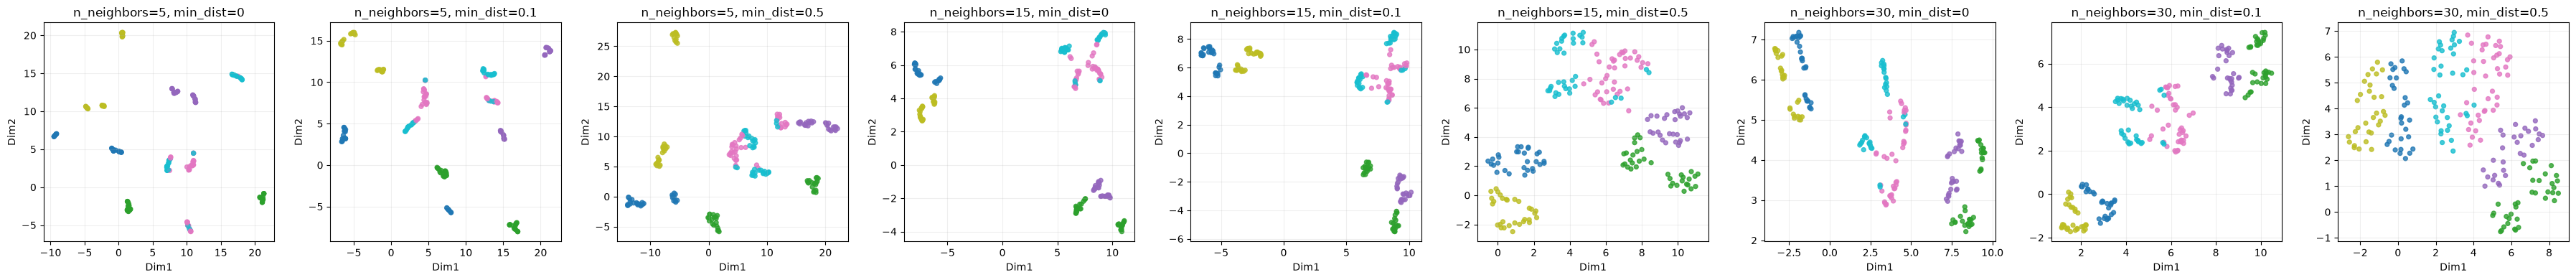

In [9]:
resultados_umap = {}
filas_umap = []
try:
    vecinos = sorted({v for v in (5, 15, 30) if v < n_muestras})
    configuraciones_umap = [(v, distancia) for v in vecinos for distancia in (0.0, 0.1, 0.5)]
    for n_vecinos, min_dist in configuraciones_umap:
        embedding = analisis.umap_embedding(n_components=2, n_neighbors=n_vecinos, min_dist=min_dist)
        nombre = f"n_neighbors={n_vecinos}, min_dist={min_dist:g}"
        resultados_umap[nombre] = embedding
        filas_umap.append({"Configuracion": nombre, "n_neighbors": n_vecinos, "min_dist": min_dist, "trustworthiness": embedding.attrs["trustworthiness"]})
except ImportError as error:
    warnings.warn(f"UMAP no disponible: {error}")

if filas_umap:
    tabla_umap = pd.DataFrame(filas_umap).sort_values("trustworthiness", ascending=False)
    display(tabla_umap.style.format({"trustworthiness": "{:.4f}"}))
    seleccion_umap_nombre = tabla_umap.iloc[0]["Configuracion"]
    seleccion_umap = resultados_umap[seleccion_umap_nombre]
    print(f"Seleccion preliminar UMAP: {seleccion_umap_nombre}")

    fig, ejes = plt.subplots(1, len(resultados_umap), figsize=(4 * len(resultados_umap), 4))
    ejes = np.atleast_1d(ejes)
    for ax, (nombre, embedding) in zip(ejes, resultados_umap.items()):
        ax.scatter(embedding.iloc[:, 0], embedding.iloc[:, 1], c=seleccion_kmeans["etiquetas"], cmap="tab10", s=18, alpha=0.8)
        ax.set(title=nombre, xlabel="Dim1", ylabel="Dim2")
        ax.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()
else:
    print("No se genero tabla UMAP porque falta umap-learn. Instale las dependencias de requirements.txt y vuelva a ejecutar.")

**Análisis t-SNE:** La configuración perplexity=30, learning_rate=auto logró la mayor trustworthiness (0.9981), preservando muy bien la vecindad local sin garantizar distancias globales.

**Análisis UMAP:** Se seleccionó n_neighbors=5, min_dist=0.5 por su alta trustworthiness (0.9944), aunque sensible al valor de n_neighbors, reflejando el trade-off entre estructura local y global.

## 5. Resumen y conclusion

| Metodo | Configuracion seleccionada | Evidencia principal | Limitacion observada |
|---|---|---|---|
| PCA | Umbral 90%, 5 componentes | 91.26% varianza acumulada explicada | Requiere más componentes de los ideales para visualización 2D |
| HAC | k=4, linkage=average | Cophenetic más alto (0.711), mejor rango compuesto (3.38) | Silhouette bajo-moderado (0.225); un cluster disperso sin región propia |
| K-Means | k=6, init=random, n_init=10 | Mayor silhouette (0.257) | Silhouette no monótono en k; clusters 4 y 5 se entremezclan en la proyección |
| t-SNE | perplexity=30, learning_rate=auto | Mayor trustworthiness (0.9981) | Preserva vecindad local, no distancias globales |
| UMAP | n_neighbors=5, min_dist=0.5 | Mayor trustworthiness (0.9944) | Alta sensibilidad a n_neighbors; trade-off local/global |

### Limitaciones
- Silhouette, Davies-Bouldin y Calinski-Harabasz evalúan geometria bajo la representacion escalada y pueden favorecer formas de cluster distintas.
- HAC y UMAP pueden ser costosos con conjuntos grandes; las configuraciones deben ajustarse al tamano de los datos.
- PCA se ajusta despues de one-hot encoding y estandarizacion; las cargas corresponden a las variables codificadas.
- Los embeddings son sensibles a hiperparametros y no conservan necesariamente distancias globales.